# 5. K-Means 비지도 학습 Unsupervised Learning / Clustering
## 강화학습에 Classification은 분류에 대한 답을 알려주고 이후 분류, Clustering은 각 집단의 특징별 분류

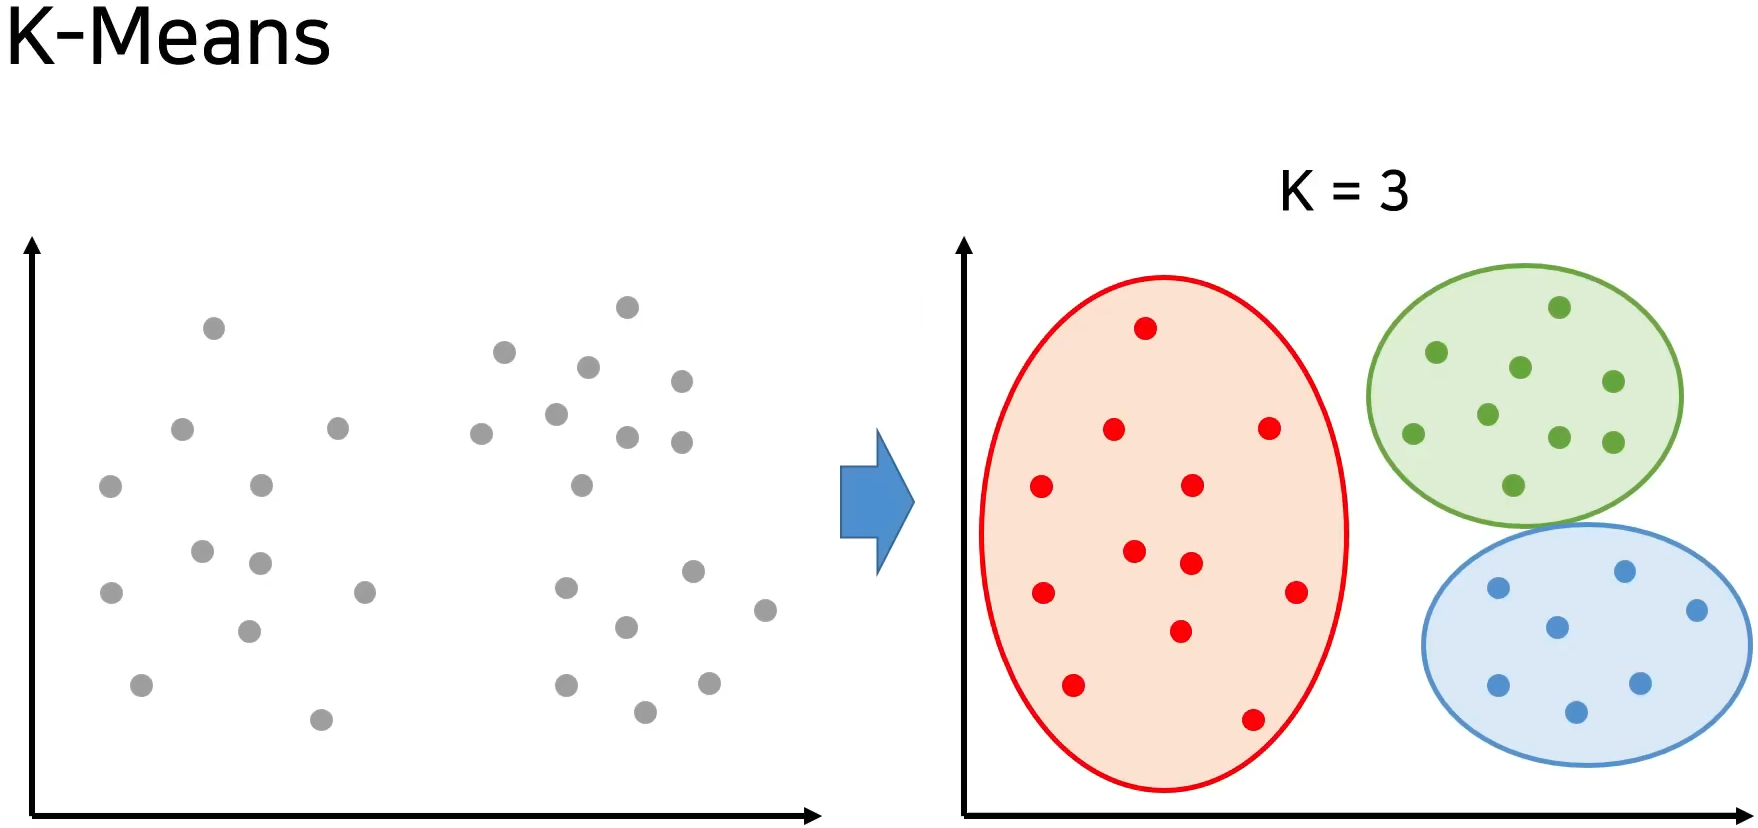

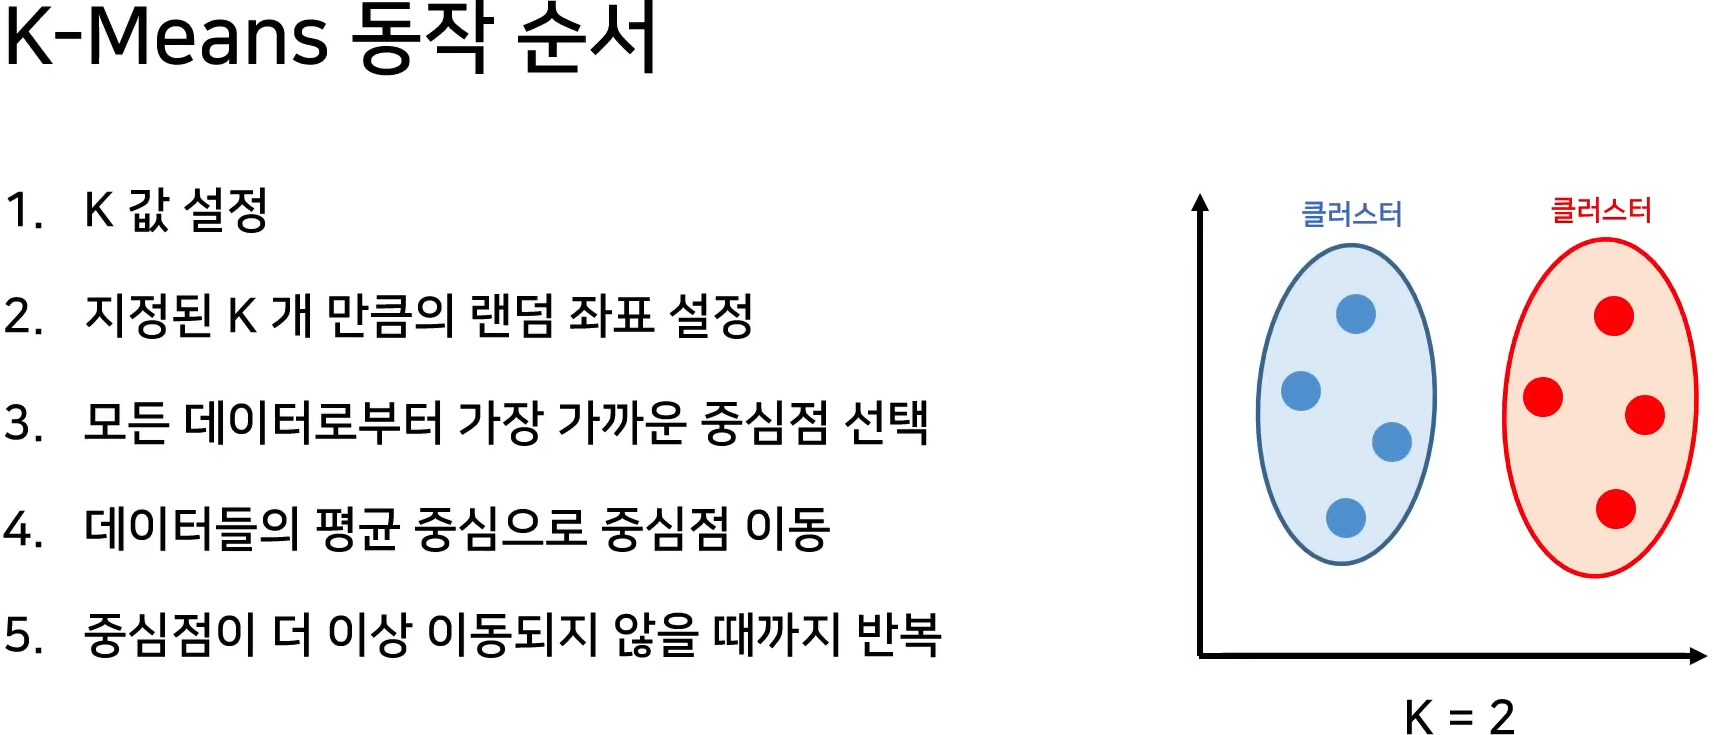

### 2번 과정에서 Random Initialization Trap 문제 해결을 위한게 K-means++

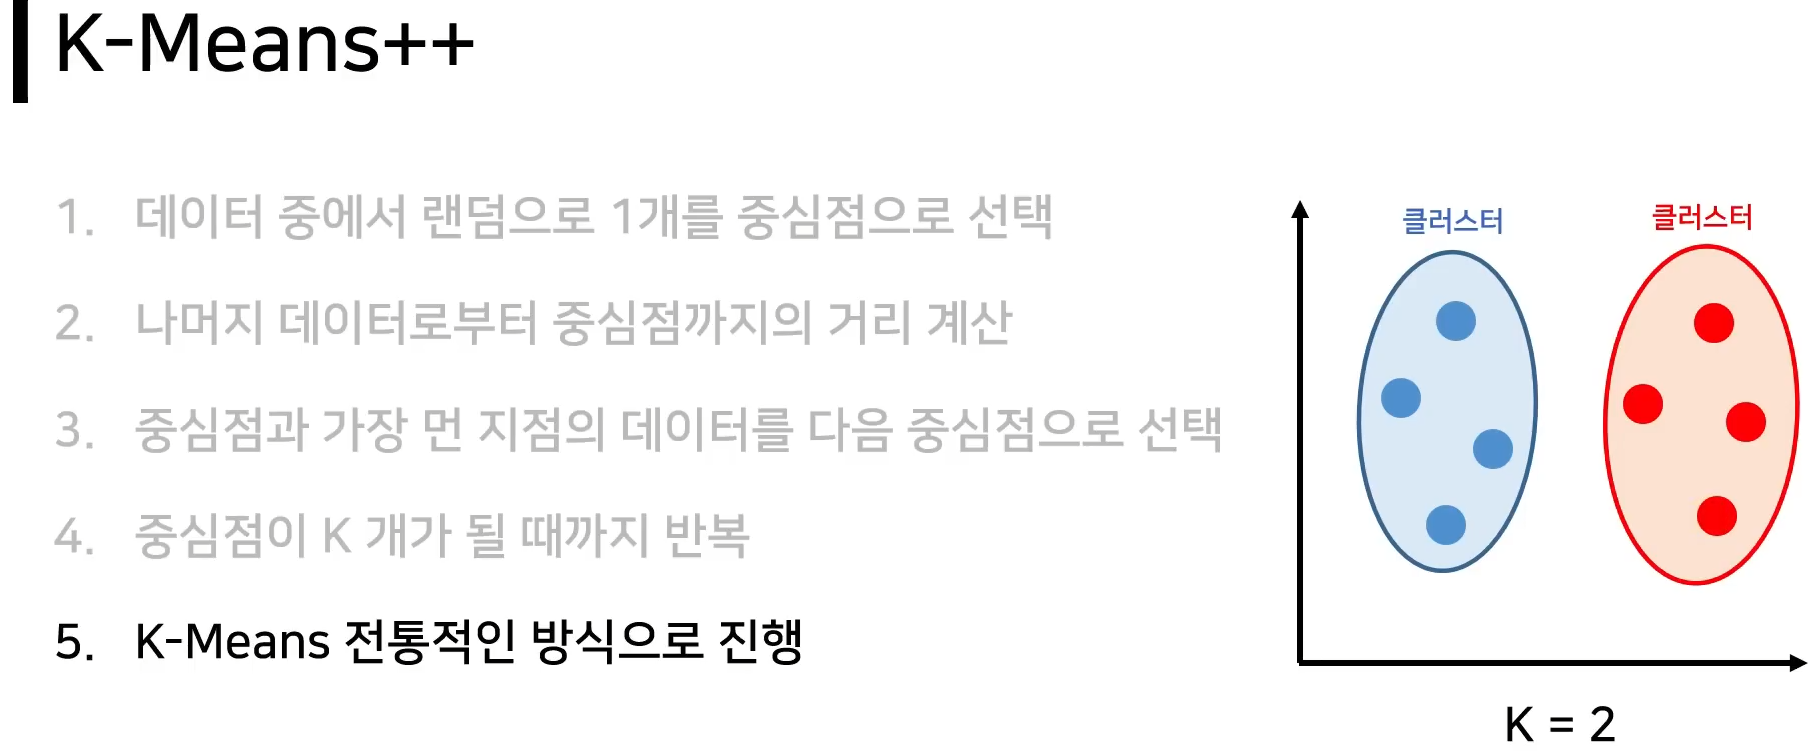

## Optimal / K 최적의 K 설정 방법

## Elbow Method
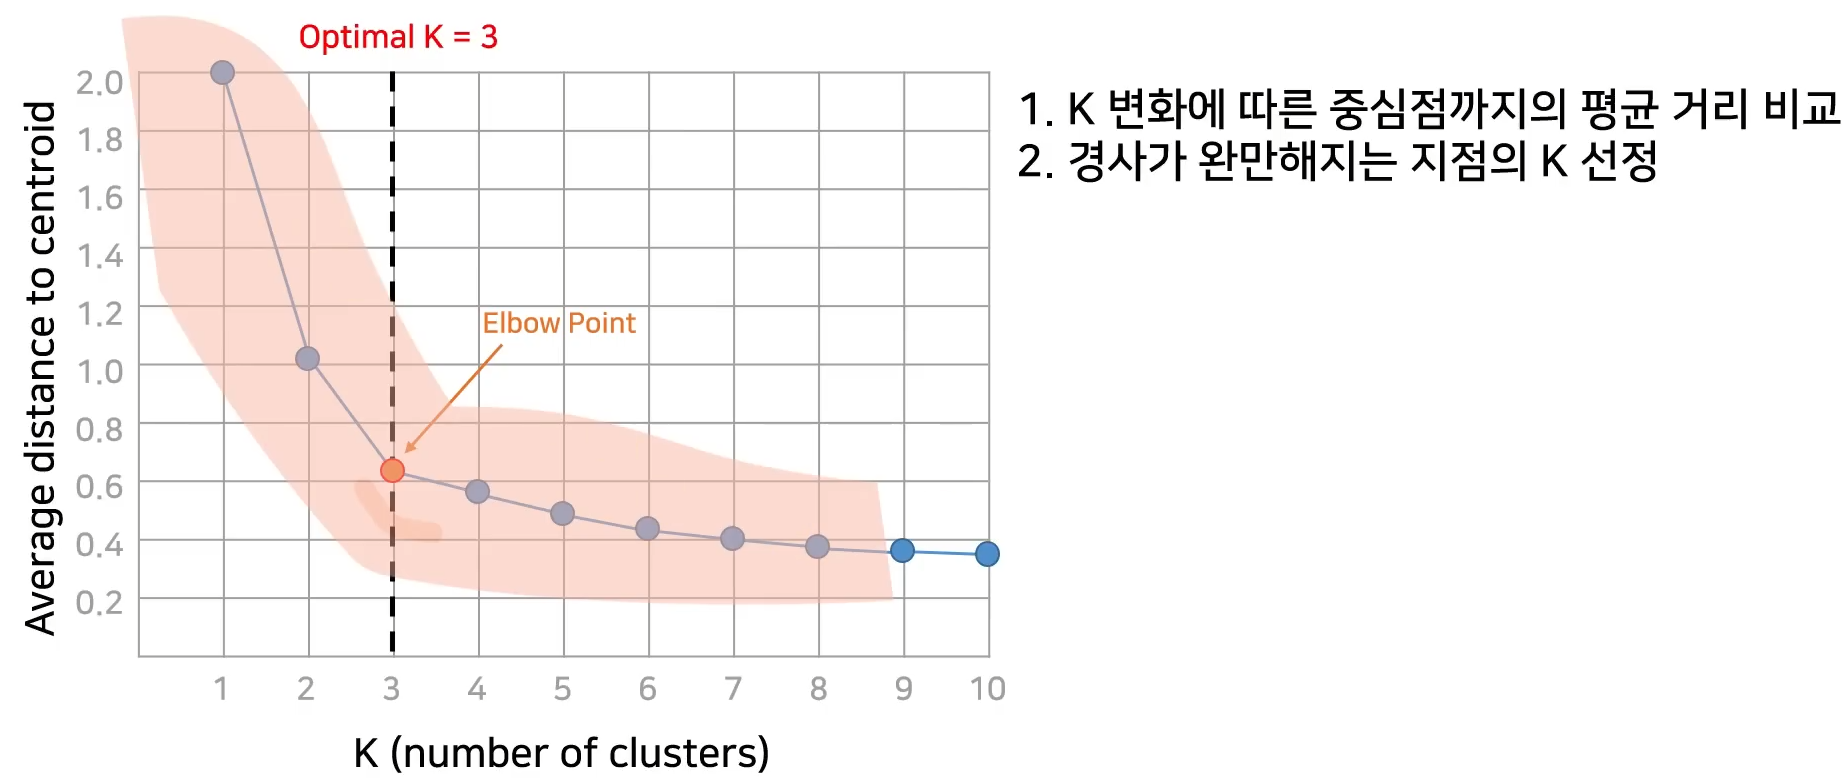

## 유사도 비교 방법
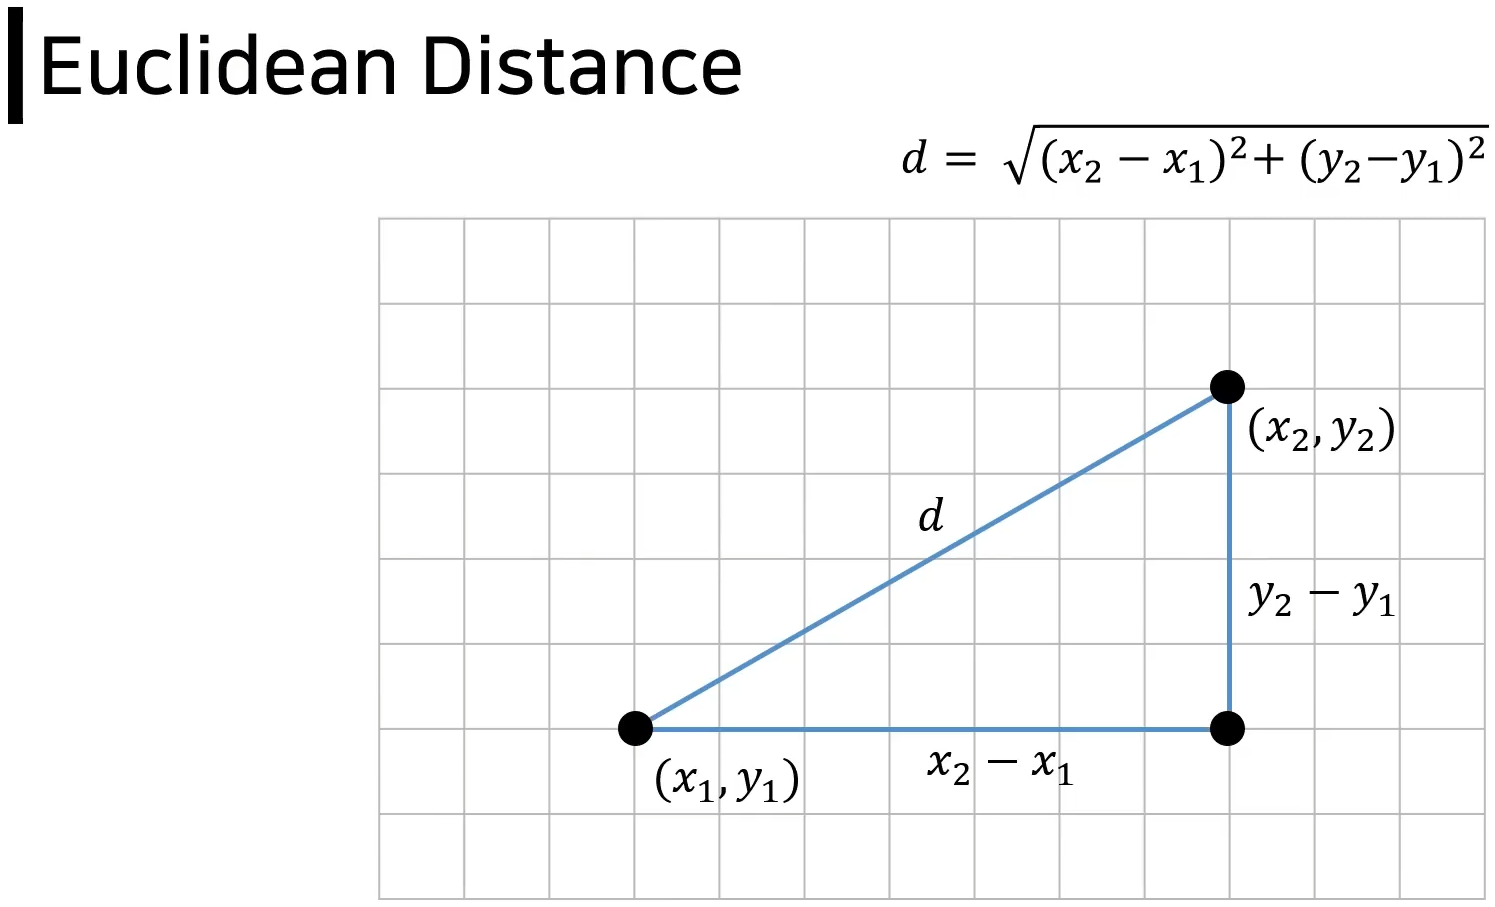
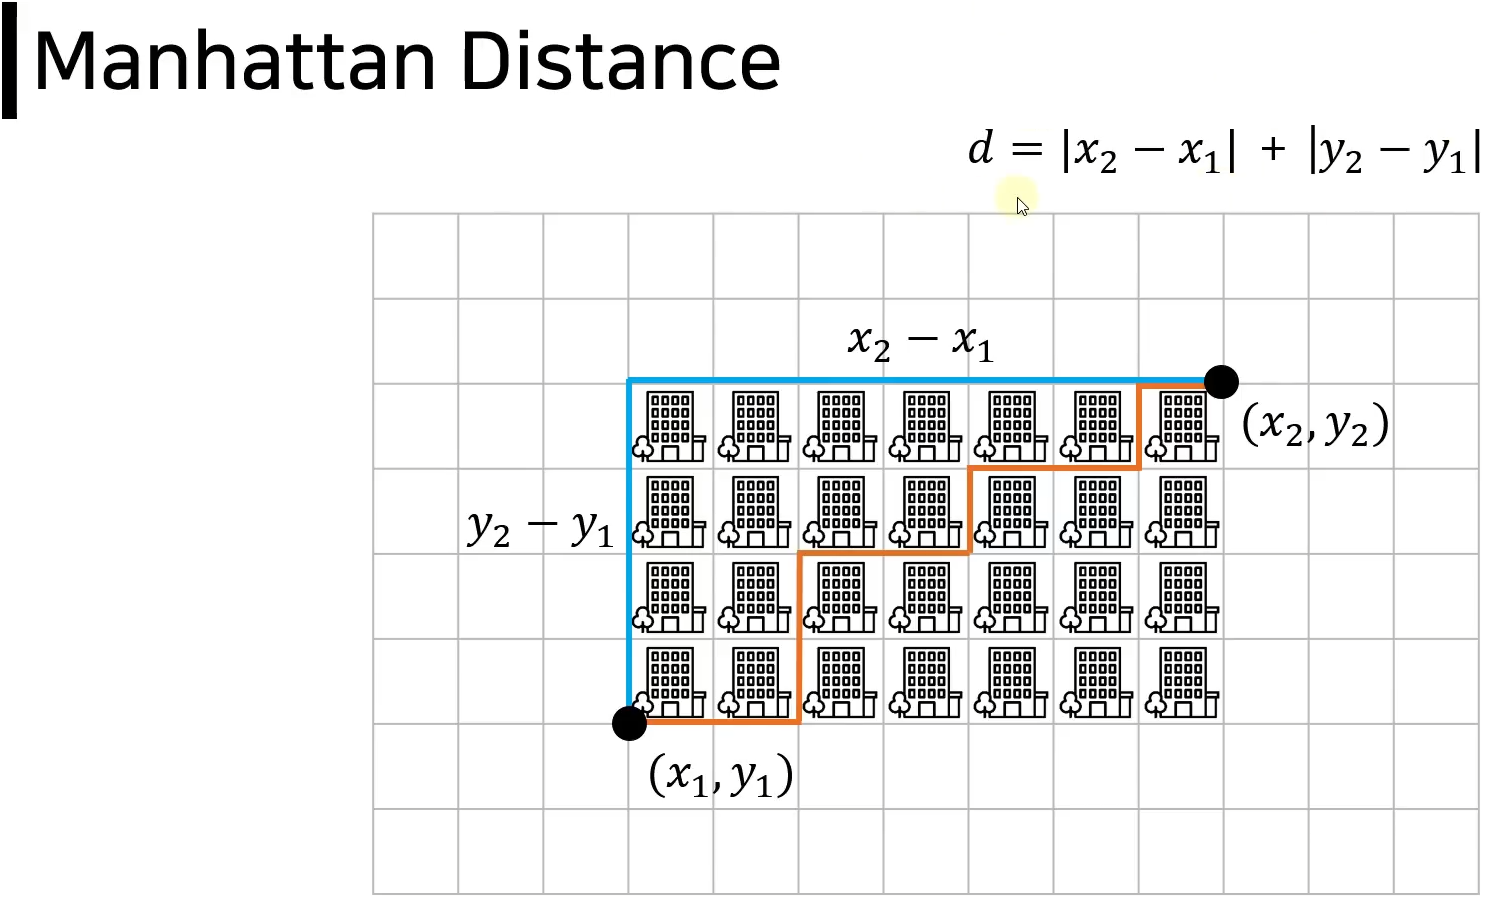
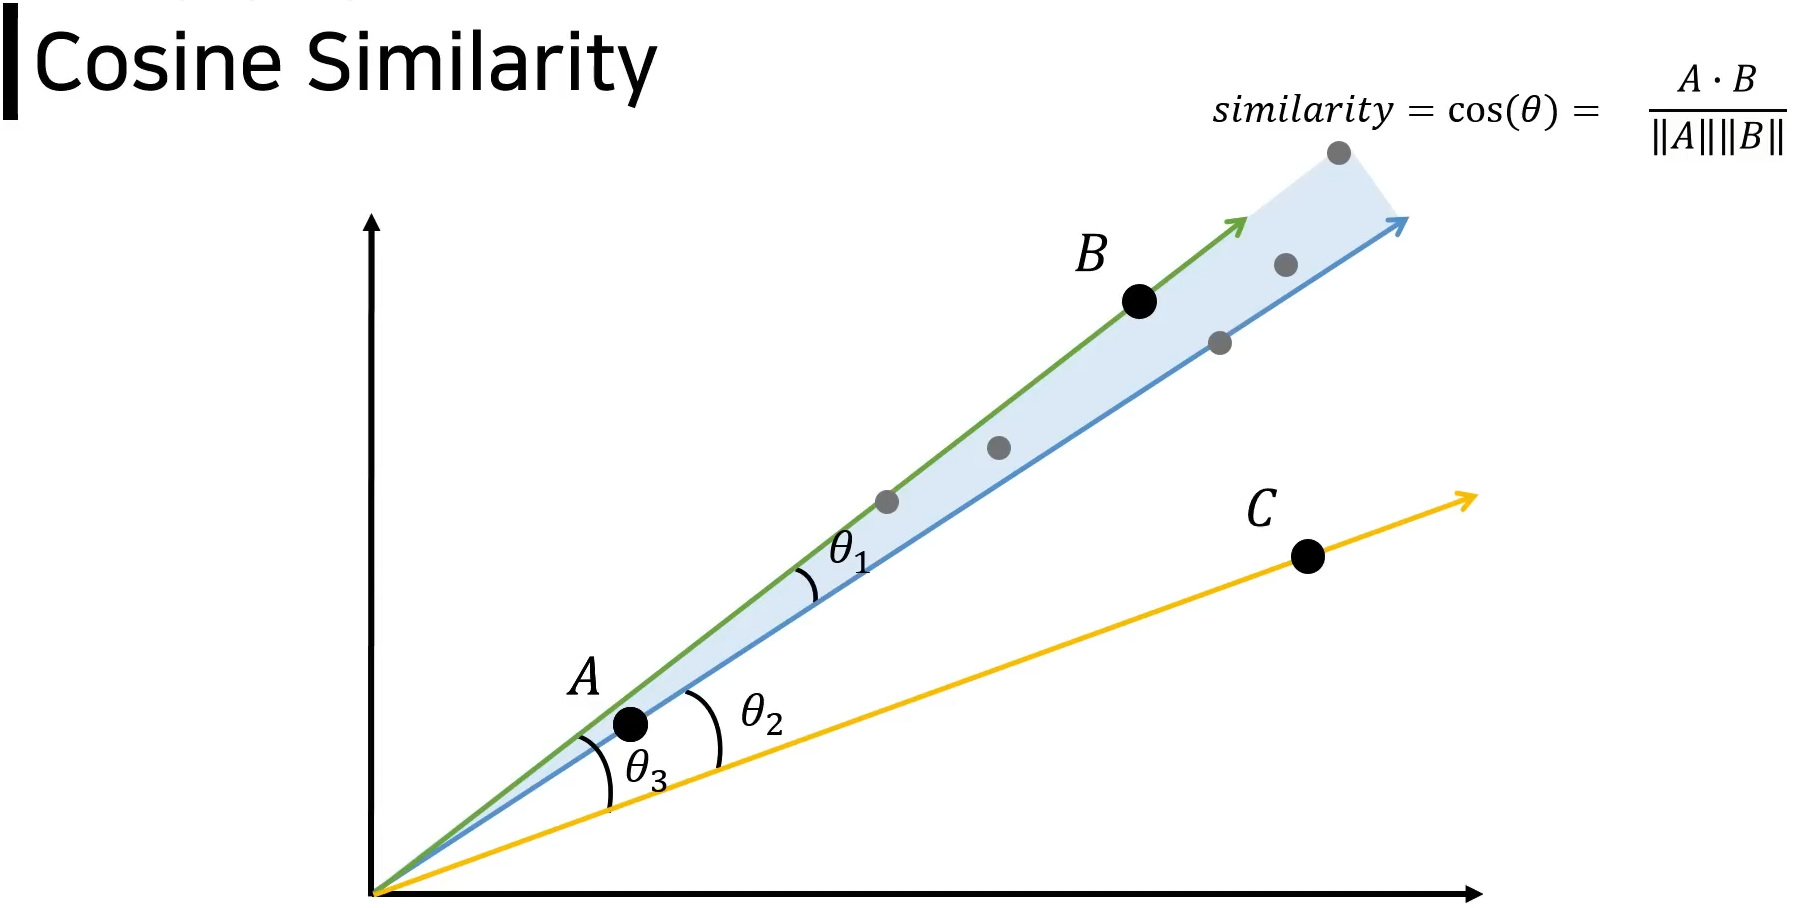

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1' #경고대응: from sklearn.preprocessing import StandardScaler 이전에 적용 해줘야함

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
dataSet = pd.read_csv('KMeansData.csv')
dataSet.head()

,hour,score
0,7.33,73
1,3.71,55
2,3.43,55
3,3.06,89
4,3.33,79


In [4]:
X = dataSet.iloc[:,:].values #X = dataSet.values, X = dataSet.to_numpy() <- 공식 홈페이지 권장
X[:5]

array([[ 7.33, 73.  ],
       [ 3.71, 55.  ],
       [ 3.43, 55.  ],
       [ 3.06, 89.  ],
       [ 3.33, 79.  ]])

### 데이터 시각화(전체 데이터 분포 확인)

<function matplotlib.pyplot.show(close=None, block=None)>

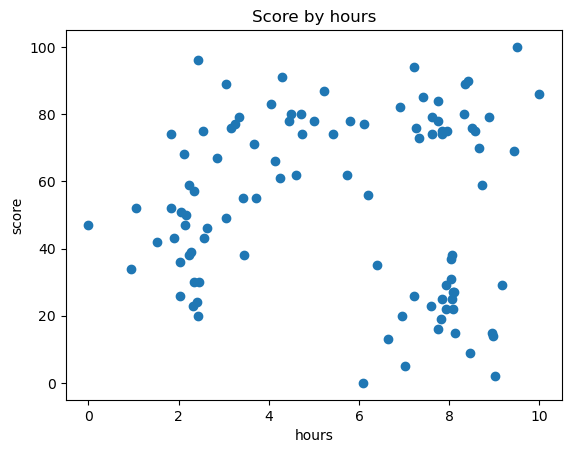

In [5]:
plt.scatter(X[:, 0], X[:, 1]) # X축: hour, y축: score
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show

### 데이터 시각화(축 범위 통일)

<function matplotlib.pyplot.show(close=None, block=None)>

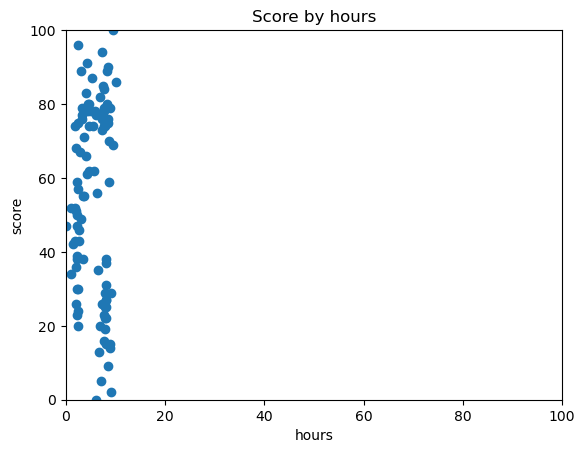

In [6]:
#축 범위를 통일하는 이유는 x축과 y축의 차이가 크면 시각적으로는 a와 b중 b가 평균 점에서 더 멀구나라고 판단하는데 실질적으로는 반대일 수 있다.
plt.scatter(X[:, 0], X[:, 1]) # X축: hour, y축: score
plt.title('Score by hours')
plt.xlabel('hours')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.ylabel('score')
plt.show

### Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)
X[:5]

array([[ 0.68729921,  0.73538376],
       [-0.66687438,  0.04198891],
       [-0.77161709,  0.04198891],
       [-0.9100271 ,  1.35173473],
       [-0.8090252 ,  0.96651537]])

### 데이터 시각화(스케일링된 데이터

<function matplotlib.pyplot.show(close=None, block=None)>

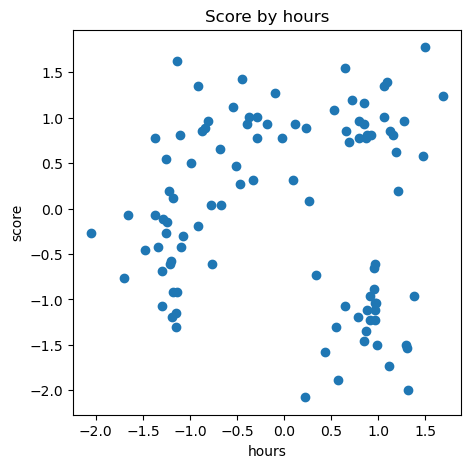

In [8]:
plt.figure(figsize=(5,5))
plt.scatter(X[:, 0], X[:, 1]) # X축: hour, y축: score
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show

### 최적의 K 값 찾기 Elbow Method

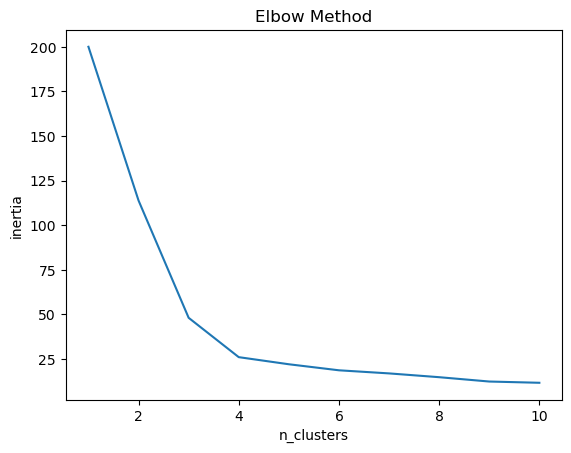

In [10]:
from sklearn.cluster import KMeans

inertia_list = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=0) #테스트 결과가 똑같이 나오게끔 random_state = 0
    '''
    n_init은 "초기 Centroid를 서로 다르게 설정해서 알고리즘을 몇 번 반복 실행할 것인가"를 결정하는 파라미터
    기본은 'auto'(k-mean++는 1번)인데 10번 또는 그 이상 실행시켜줘서 가장 좋은 결과를 선택한다.
    난 10으로 설정할 것임
    '''
    kmeans.fit(X)
    inertia_list.append(kmeans. inertia_) #각 지점으로부터 클러스터의 중심(Centroid)까지 거리의 제곱의 합

plt.plot(range(1,11), inertia_list)
plt.title('Elbow Method')
plt.xlabel('n_clusters')
plt.ylabel('inertia')
plt.show()

### 최적의 K(4) 값으로 KMeans 학습

In [12]:
kmeans = KMeans(n_clusters = 4, n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(X) 
y_kmeans

array([2, 3, 3, 0, 0, 1, 1, 0, 2, 0, 0, 3, 1, 3, 3, 0, 1, 2, 3, 0, 1, 0,
       3, 1, 2, 2, 3, 3, 3, 3, 1, 1, 3, 0, 2, 2, 3, 0, 0, 0, 3, 1, 2, 3,
       3, 2, 1, 0, 1, 1, 2, 0, 1, 1, 0, 0, 0, 0, 3, 1, 1, 2, 2, 2, 2, 1,
       1, 0, 1, 2, 3, 2, 2, 2, 3, 3, 3, 3, 0, 2, 1, 2, 1, 1, 2, 0, 3, 1,
       2, 3, 0, 1, 0, 2, 3, 2, 2, 0, 1, 3])

### 데이터 시각화(최적의 K)

In [15]:
centers = kmeans.cluster_centers_ #클러스터의 centroid 좌표
centers

array([[-0.57163957,  0.85415973],
       [ 0.8837666 , -1.26929779],
       [ 0.94107583,  0.93569782],
       [-1.22698889, -0.46768593]])

<function matplotlib.pyplot.show(close=None, block=None)>

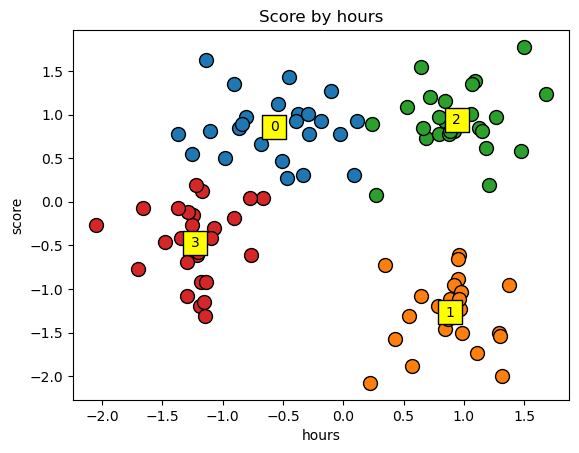

In [20]:
for cluster in range(4):
    #cluster숫자에 맞는 index별 산점도, 0=공부시간, 1=점수, s=점 사이즈, edgecolor=점 테두리 색
    plt.scatter(X[y_kmeans == cluster, 0], X[y_kmeans == cluster, 1], s=100, edgecolor='black')
    
    #4개의 cluster centroid, marker=모양
    plt.scatter(centers[cluster, 0], centers[cluster, 1], s=300, edgecolor='black', color='yellow', marker='s')
    
    #cluster 텍스트 출력
    plt.text(centers[cluster, 0], centers[cluster, 1], cluster, va='center', ha='center')
    
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show

### 데이터 시각화(스케일링 원복)
#### 스케일링 후에 시각화 데이터가 각 feature별 데이터의 값이 정확히 몇인지 알 수 없기 때문 

In [21]:
X_org = sc.inverse_transform(X) #Feature Scaling된 데이터 원복
X_org[:5]

array([[ 7.33, 73.  ],
       [ 3.71, 55.  ],
       [ 3.43, 55.  ],
       [ 3.06, 89.  ],
       [ 3.33, 79.  ]])

In [27]:
#Feature Scaling된 centroid 데이터 원복
centers_org = sc.inverse_transform(centers)
centers_org[:5]

array([[ 3.96458333, 76.08333333],
       [ 7.8552    , 20.96      ],
       [ 8.0084    , 78.2       ],
       [ 2.21269231, 41.76923077]])

<function matplotlib.pyplot.show(close=None, block=None)>

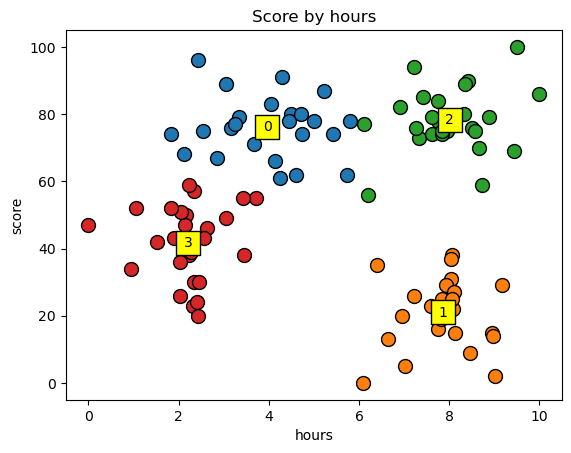

In [25]:
for cluster in range(4):
    #cluster숫자에 맞는 index별 산점도, 0=공부시간, 1=점수, s=점 사이즈, edgecolor=점 테두리 색
    plt.scatter(X_org[y_kmeans == cluster, 0], X_org[y_kmeans == cluster, 1], s=100, edgecolor='black')
    
    #4개의 cluster centroid, marker=모양
    plt.scatter(centers_org[cluster, 0], centers_org[cluster, 1], s=300, edgecolor='black', color='yellow', marker='s')
    
    #cluster 텍스트 출력
    plt.text(centers_org[cluster, 0], centers_org[cluster, 1], cluster, va='center', ha='center')
    
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show